dx=0.02, dt=0.01, CFL=0.5


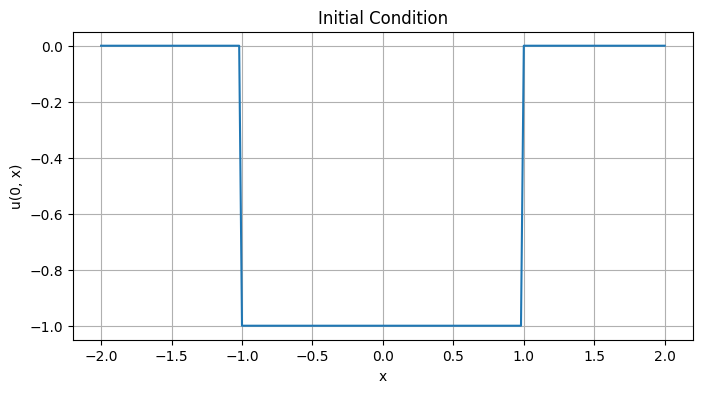

/var/folders/xd/6b7x17ts5b7612cqwyl3b63m0000gp/T/ipykernel_61459/3645324835.py:55: RuntimeWarning: overflow encountered in scalar power
  v[i] = u[i] - dt/dx * (u[i]**2 - u[i-1]**2)
/var/folders/xd/6b7x17ts5b7612cqwyl3b63m0000gp/T/ipykernel_61459/3645324835.py:55: RuntimeWarning: invalid value encountered in scalar subtract
  v[i] = u[i] - dt/dx * (u[i]**2 - u[i-1]**2)


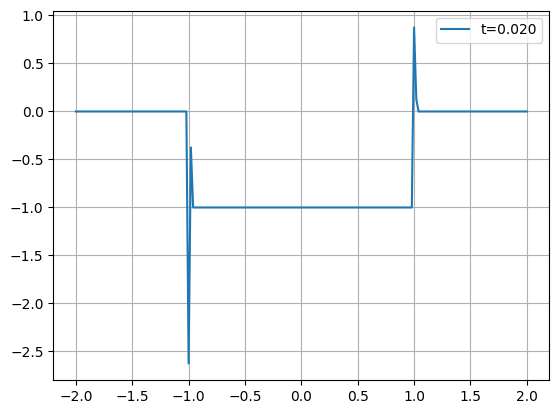

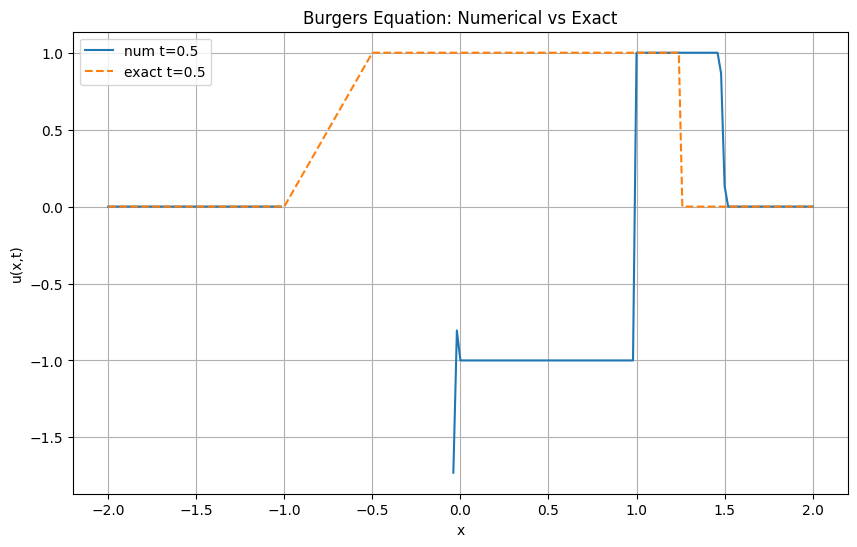

In [1]:
import numpy as np
import matplotlib.pyplot as plt


a, b = -2, 2
dx = 0.02
dt = 0.01
T_e = 2
gam = dt/dx

print(f"dx={dx}, dt={dt}, CFL={gam}")

x = np.arange(a, b + dx, dx)

def u0(x):
    return np.where((x >= -1) & (x <= 1), -1.0, 0.0)

u = u0(x)


plt.figure(figsize=(8, 4))
plt.plot(x, u)
plt.title("Initial Condition")
plt.xlabel("x")
plt.ylabel("u(0, x)")
plt.grid()
plt.show()


save_times = [0.5]
saved_num = {}
saved_exact = {}

t = dt

def u_exact(x, t):
    u = np.zeros_like(x)

    left = x < -1
    rare = (x >= -1) & (x <= -1 + t)
    middle = (x >= -1 + t) & (x <= 1 + 0.5*t)
    right = x > 1 + 0.5*t

    u[left] = 0
    u[rare] = (x[rare] + 1) / t
    u[middle] = 1
    u[right] = 0

    return u

while t <= T_e:
    v = np.zeros_like(u)

    for i in range(1, len(u)):
        v[i] = u[i] - dt/dx * (u[i]**2 - u[i-1]**2)

    v[0] = u[0] - dt/dx * (u[0]**2 -u[-1]**2)
    if np.isclose(t, 2*dt):
        plt.plot(x, v, label=f"t={t:.3f}")
        plt.legend()
        plt.grid()

    u = v.copy()

    for ts in save_times:
        if abs(t - ts) < dt/2:
            saved_num[ts] = u.copy()

            saved_exact[ts] = u_exact(x, ts)

    t += dt

plt.figure(figsize=(10, 6))

for ts in save_times:
    if ts in saved_num:
        plt.plot(x, saved_num[ts], label=f"num t={ts}")
        plt.plot(x, saved_exact[ts], '--', label=f"exact t={ts}")

plt.title("Burgers Equation: Numerical vs Exact")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.legend()
plt.grid()
plt.show()

In [17]:
print(v)

[0.75437461 0.7592788  0.7641839  0.76908998 0.77399707 0.77890522
 0.7838145  0.78872495 0.79363664 0.79854964 0.80346401 0.80837984
 0.8132972  0.81821619 0.8231369  0.82805943 0.83298391 0.83791045
 0.84283919 0.84777029 0.8527039  0.85764021 0.86257942 0.86752175
 0.87246746 0.87741683 0.88237017 0.88732784 0.89229026 0.89725789
 0.90223128 0.90721106 0.91219797 0.91719289 0.92219687 0.92721119
 0.93223741 0.93727747 0.94233386 0.94740979 0.95250954 0.95763899
 0.96280658 0.96802501 0.97331489 0.97871319 0.98429764 0.98128085
 0.5        0.00901523 0.00970432 0.01570196 0.02128681 0.02668511
 0.03197499 0.03719342 0.04236101 0.04749046 0.05259021 0.05766614
 0.06272253 0.06776259 0.07278881 0.07780313 0.08280711 0.08780203
 0.09278894 0.09776872 0.10274211 0.10770974 0.11267216 0.11762983
 0.12258317 0.12753254 0.13247825 0.13742058 0.14235979 0.1472961
 0.15222971 0.15716081 0.16208955 0.16701609 0.17194057 0.1768631
 0.18178381 0.1867028  0.19162016 0.19653599 0.20145036 0.206363